## **Ejercicio 1**

### Descripcion
*El dataset contiene información sobre los costumers. Uno de los atributos es ‘Churn’, que es nuestra variable target, la que queremos predecir.* 

*Churn nos dice si el customer dejó de usar el servicio o no en el último mes.*

*Nuestro objetivo es predecir este comportamiento de los customers para lograr retenerlos.*

In [23]:
import pandas as pd
df = pd.read_csv('info_customers.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [24]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Analisis Exploratorio


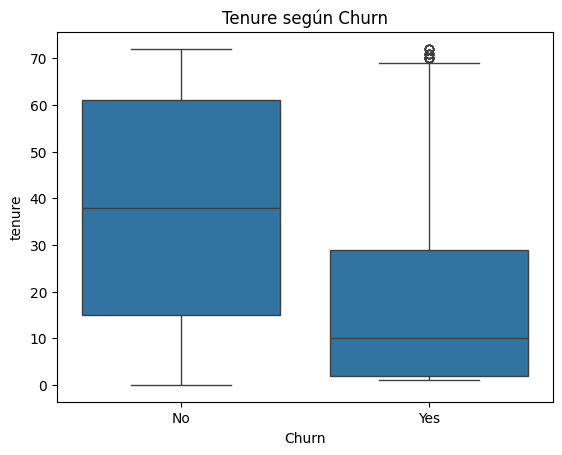

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure según Churn")
plt.show()

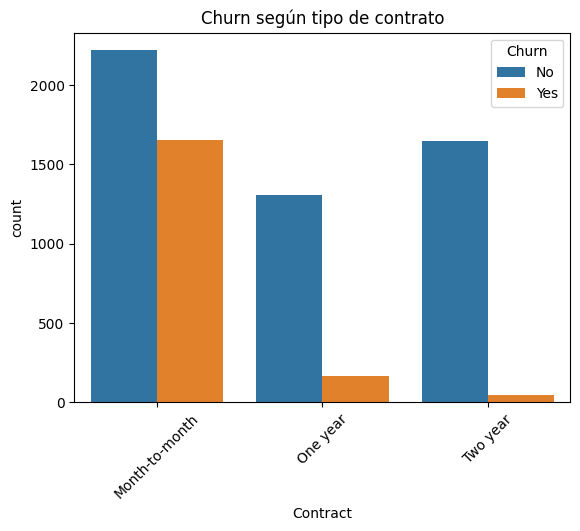

In [26]:
sns.countplot(data=df, x="Contract", hue="Churn")
plt.xticks(rotation=45)
plt.title("Churn según tipo de contrato")
plt.show()

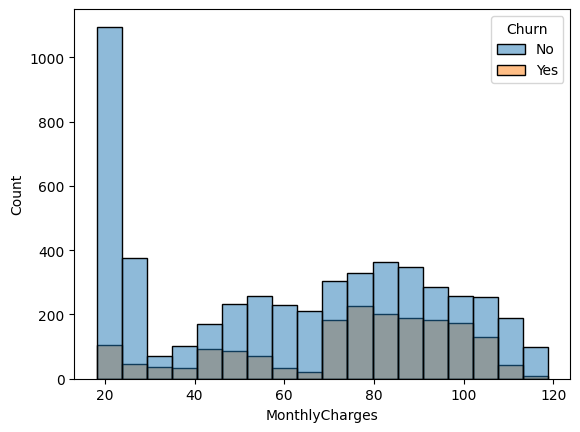

In [27]:
# Histograma
sns.histplot(x = "MonthlyCharges", hue = "Churn", data = df)

plt.show()

### Algunas columnas no son reconocidas como numericas
*Esto sucede porque algunas de las variables son categoricas, por lo que, en primera instancia, no las puedo pensar como variables numericas.*

*Usando la funcion get.dummies(), puedo crear una columna de cada valor de las varibles categoricas, de esa forma, se las puede pensar como variables numericas con valores 0 o 1*

*Por Ejemplo: La columna Genre (con valores Female o Male) la puedo tirar y crear dos columnas que sean Genre_Male y Genre_Female que digan si es cierto que ese cliente es un hombre o una mujer respectivamente*

In [28]:
# Veo el tipo de dato
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [29]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [30]:
for col in df.columns:
    if col != 'customerID':
        print(f"\nColumna: {col}")
        print(df[col].value_counts())


Columna: gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

Columna: SeniorCitizen
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

Columna: Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Columna: Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

Columna: tenure
tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64

Columna: PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

Columna: MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

Columna: InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

Columna: OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

Co

In [31]:
df = pd.get_dummies(df, columns=["gender", "Partner", "Dependents", "Contract", "Churn", "PaymentMethod", "PaperlessBilling", "StreamingMovies", "StreamingTV", "TechSupport", "DeviceProtection", "OnlineBackup", "OnlineSecurity", "InternetService", "MultipleLines", "PhoneService"])
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

*Borro Las columnas customerID y Churn_No, ya que no tiene sentido usarlas. customerID solo identifica al cliente y mi variable target tiene mas sentido que sea Churn_Yes*

In [32]:
df = df.drop(columns=["customerID"])
df = df.drop(columns=["Churn_No"])

*Ahora todas las columnas son numericas.*

In [33]:
df.dtypes

SeniorCitizen                                int64
tenure                                       int64
MonthlyCharges                             float64
TotalCharges                               float64
gender_Female                                 bool
gender_Male                                   bool
Partner_No                                    bool
Partner_Yes                                   bool
Dependents_No                                 bool
Dependents_Yes                                bool
Contract_Month-to-month                       bool
Contract_One year                             bool
Contract_Two year                             bool
Churn_Yes                                     bool
PaymentMethod_Bank transfer (automatic)       bool
PaymentMethod_Credit card (automatic)         bool
PaymentMethod_Electronic check                bool
PaymentMethod_Mailed check                    bool
PaperlessBilling_No                           bool
PaperlessBilling_Yes           

In [34]:
df['gender_Female'].head(10)

0     True
1    False
2    False
3    False
4     True
5     True
6    False
7     True
8     True
9    False
Name: gender_Female, dtype: bool

 ## **Ejercicio 2**

*Antes de resolver el problema de los valores nulos, tengo que separar la muestra.*
*Si no, estaria haciendo Data Leakage. Porque estaria usando informacion del test para el training.*

## **Valores Faltantes**

*Se reemplazan los valores faltantes por la media para mantener un valor representativo sin alterar significativamente la distribución de los datos.*

In [35]:
# Separo Training y Test
from sklearn.model_selection import train_test_split

X = df.drop("Churn_Yes", axis=1)
y = df["Churn_Yes"]

# Training (80%), Test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [36]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")
imputer.fit(X_train)
X_train = imputer.transform(X_train)
X_test = imputer.transform(X_test)

## **Escalado**

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [38]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# K-FOLD
kf = KFold(n_splits=5, shuffle=True, random_state=42)

accuracies = []
precisions = []
recalls = []
f1s = []
X_train_df = pd.DataFrame(X_train)
for train_index, val_index in kf.split(X_train):
    
    # separar datos
    X_train_fold = X_train_df.iloc[train_index].copy()
    X_val_fold = X_train_df.iloc[val_index].copy()
    y_train_fold = y.iloc[train_index]
    y_val_fold = y.iloc[val_index]

    # modelo
    modelo = KNeighborsClassifier(n_neighbors=10)
    modelo.fit(X_train_fold, y_train_fold)

    # predicción
    y_pred = modelo.predict(X_val_fold)

    # métricas
    acc = accuracy_score(y_val_fold, y_pred)
    prec = precision_score(y_val_fold, y_pred)
    rec = recall_score(y_val_fold, y_pred)
    f1 = f1_score(y_val_fold, y_pred)
    cm = confusion_matrix(y_val_fold, y_pred)

    # guardar
    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)
    f1s.append(f1)

    print("Confusion matrix:\n", cm)
    print("------")

# resultados finales
print("Accuracy promedio:", np.mean(accuracies))
print("Precision promedio:", np.mean(precisions))
print("Recall promedio:", np.mean(recalls))
print("F1-score promedio:", np.mean(f1s))

Confusion matrix:
 [[804  23]
 [289  11]]
------
Confusion matrix:
 [[800  18]
 [296  13]]
------
Confusion matrix:
 [[803  18]
 [298   8]]
------
Confusion matrix:
 [[824  13]
 [282   8]]
------
Confusion matrix:
 [[821  22]
 [272  11]]
------
Accuracy promedio: 0.7282588995131607
Precision promedio: 0.35297245449048104
Recall promedio: 0.034267423954884975
F1-score promedio: 0.06231976425897258


In [39]:
modelo = KNeighborsClassifier(n_neighbors=10)
modelo.fit(X_train, y_train)

# predicción
y_pred = modelo.predict(X_test)

# métricas
accuracy_Test = accuracy_score(y_test, y_pred)
precision_Test = precision_score(y_test, y_pred)
recall_Test = recall_score(y_test, y_pred)
f1s_Test = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:\n", cm)
print("------")

# resultados finales
print("Accuracy promedio:", accuracy_Test)
print("Precision promedio:", precision_Test)
print("Recall promedio:", recall_Test)
print("F1-score promedio:", f1s_Test)

Confusion matrix:
 [[914 121]
 [205 169]]
------
Accuracy promedio: 0.7686302342086586
Precision promedio: 0.5827586206896552
Recall promedio: 0.45187165775401067
F1-score promedio: 0.5090361445783133


## **Parte II: Reformulando el problema**

*La columna que elegimos usar como nuevo target es SeniorCitizen*

*Vamos a intentar predecir si el cliente es un Senior Citizen o no*

In [41]:
from sklearn.linear_model import LogisticRegression
X = df.drop("SeniorCitizen", axis=1)
y = df["SeniorCitizen"]

# Training (80%), Test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Imputer
imputer = SimpleImputer(strategy="mean")
imputer.fit(X_train)
X_train = imputer.transform(X_train)
X_test = imputer.transform(X_test)

modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)

# predicción
y_pred = modelo.predict(X_test)

# métricas
accuracy_Test = accuracy_score(y_test, y_pred)
precision_Test = precision_score(y_test, y_pred)
recall_Test = recall_score(y_test, y_pred)
f1s_Test = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:\n", cm)
print("------")

# resultados finales
print("Accuracy promedio:", accuracy_Test)
print("Precision promedio:", precision_Test)
print("Recall promedio:", recall_Test)
print("F1-score promedio:", f1s_Test)

Confusion matrix:
 [[1159   22]
 [ 207   21]]
------
Accuracy promedio: 0.837473385379702
Precision promedio: 0.4883720930232558
Recall promedio: 0.09210526315789473
F1-score promedio: 0.15498154981549817


c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
